In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import cv2

from tensorflow.keras.models import Sequential
from tensorflow import keras
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout , Input
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

In [6]:
import tensorflow as tf

SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
images = np.load('/content/CovidImages.npy')

In [9]:
labels = pd.read_csv('/content/CovidLabels.csv')

In [10]:
print(images.shape)

(251, 128, 128, 3)


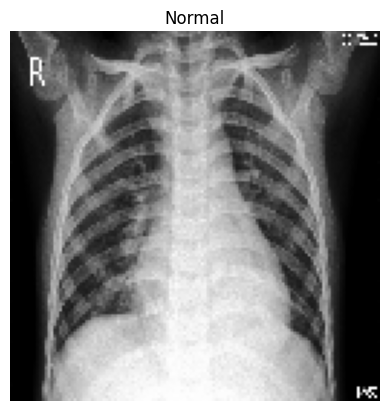

In [11]:
plt.imshow(images[5])
plt.title(labels.iloc[5, 0])
plt.axis('off')
plt.show()

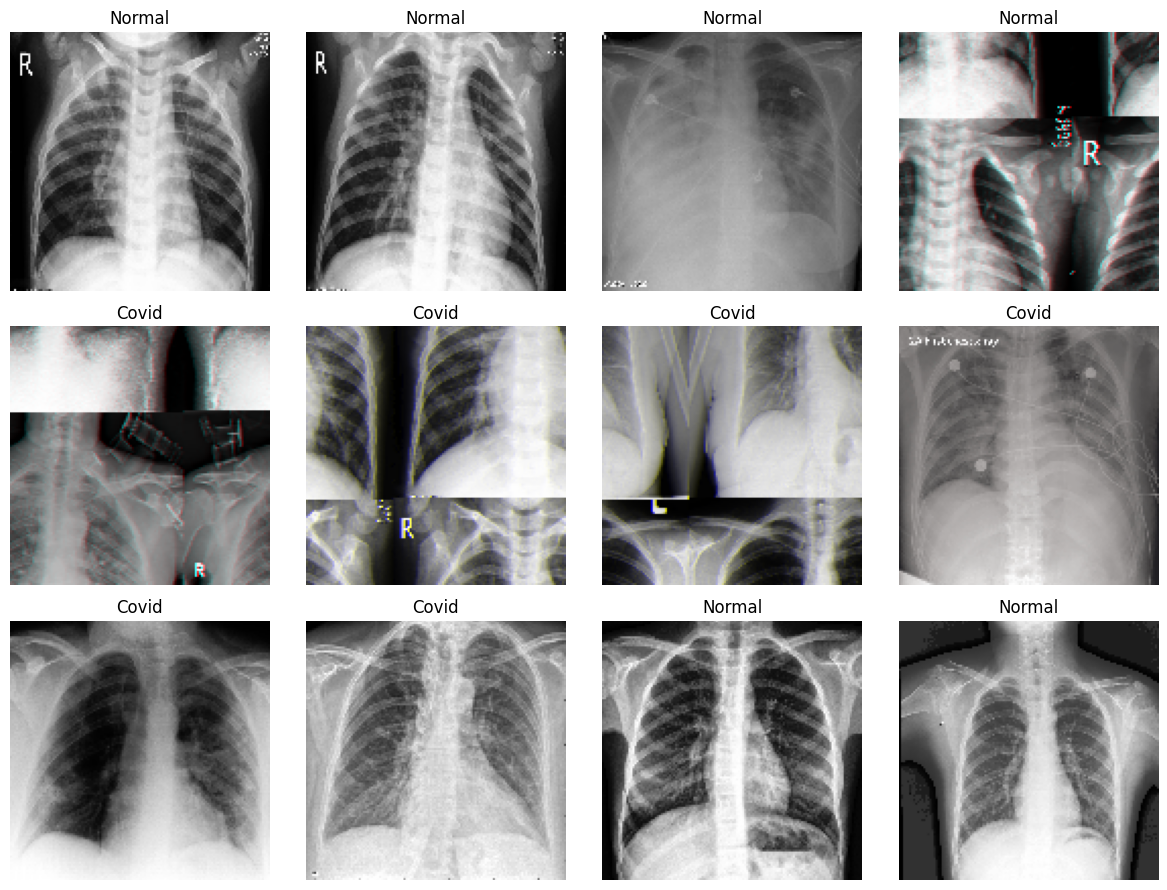

In [12]:
plt.figure(figsize=(12, 9))
for i in range(12):
  plt.subplot(3, 4, i+1)
  plt.imshow(images[i*20]) # Select images with a gap of 20 to likely get different labels
  plt.title(labels.iloc[i*20, 0])
  plt.axis('off')
plt.tight_layout()
plt.show()

/tmp/ipykernel_754/4204820766.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Label', data=labels, palette='viridis')


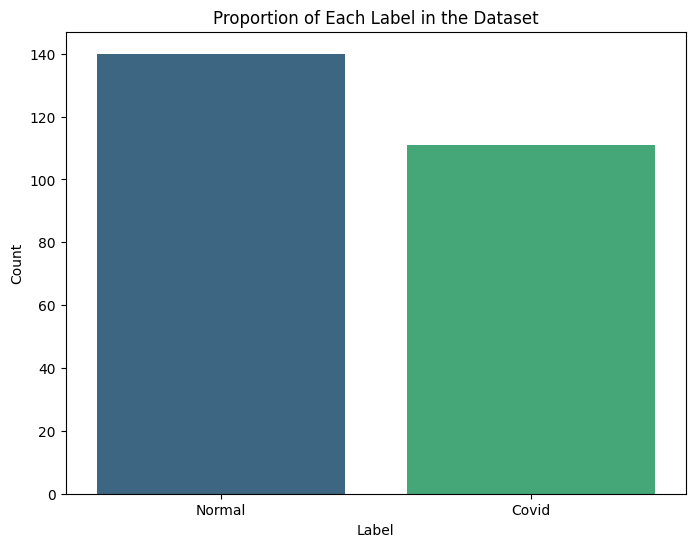

In [13]:
plt.figure(figsize=(8, 6))
sns.countplot(x='Label', data=labels, palette='viridis')
plt.title('Proportion of Each Label in the Dataset')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()

In [14]:
labels['Label'] = labels['Label'].map({'Covid': 1, 'Normal': 0})

In [15]:
X_train, X_temp, y_train, y_temp = train_test_split(images, labels['Label'], test_size=0.3, random_state=42, stratify=labels['Label'])


X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"Training set shape: {X_train.shape}, {y_train.shape}")
print(f"Validation set shape: {X_val.shape}, {y_val.shape}")
print(f"Test set shape: {X_test.shape}, {y_test.shape}")

Training set shape: (175, 128, 128, 3), (175,)
Validation set shape: (38, 128, 128, 3), (38,)
Test set shape: (38, 128, 128, 3), (38,)


In [16]:
X_train_normalized = X_train / 255.0
X_val_normalized = X_val / 255.0
X_test_normalized = X_test / 255.0

print(f"Normalized training set min/max: {X_train_normalized.min()}/{X_train_normalized.max()}")
print(f"Normalized validation set min/max: {X_val_normalized.min()}/{X_val_normalized.max()}")
print(f"Normalized test set min/max: {X_test_normalized.min()}/{X_test_normalized.max()}")

Normalized training set min/max: 0.0/1.0
Normalized validation set min/max: 0.0/1.0
Normalized test set min/max: 0.0/1.0


MODEL 1

In [27]:
model_cnn2 = Sequential([
    Input(shape=(128, 128, 3)),
    Conv2D(32,(3, 3), activation='relu',padding="valid"),
    MaxPooling2D(2, 2),

    Conv2D(64,(3, 3), activation='relu',padding="valid"),
    MaxPooling2D(2, 2),

    Flatten(),
    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid')
])


In [28]:
model_cnn2.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,392,449 (28.20 MB)

 Trainable params: 7,392,449 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

In [47]:
batch_size=32
epochs=10
model_cnn2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

start_time  = time.time()
history_cnn2 = model_cnn2.fit(X_train_normalized, y_train, batch_size=batch_size, epochs=epochs, validation_data=(X_val_normalized, y_val))
end_time = time.time()


Epoch 1/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 746ms/step - accuracy: 0.9200 - loss: 0.2878 - val_accuracy: 0.8684 - val_loss: 0.9181
Epoch 2/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 720ms/step - accuracy: 0.9371 - loss: 0.1972 - val_accuracy: 0.8158 - val_loss: 1.0249
Epoch 3/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 973ms/step - accuracy: 0.9714 - loss: 0.0916 - val_accuracy: 0.8421 - val_loss: 0.4786
Epoch 4/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 703ms/step - accuracy: 0.9886 - loss: 0.0471 - val_accuracy: 0.8421 - val_loss: 0.4758
Epoch 5/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.9886 - loss: 0.0380 - val_accuracy: 0.8684 - val_loss: 0.5178
Epoch 6/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 709ms/step - accuracy: 0.9886 - loss: 0.0264 - val_accuracy: 0.8947 - val_loss: 0.5693
Epoch 7/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 784ms/step - accuracy: 1.0000 - loss: 0.0194 - val_accuracy: 0.8947 - val_loss: 0.6266
Epoch 8/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 915ms/step - accuracy: 0.9943 - loss: 0.0132 - val_accuracy: 0.8947 - val_loss: 0.

In [48]:
print(f"Training time: {end_time - start_time} seconds")

Training time: 68.51992106437683 seconds


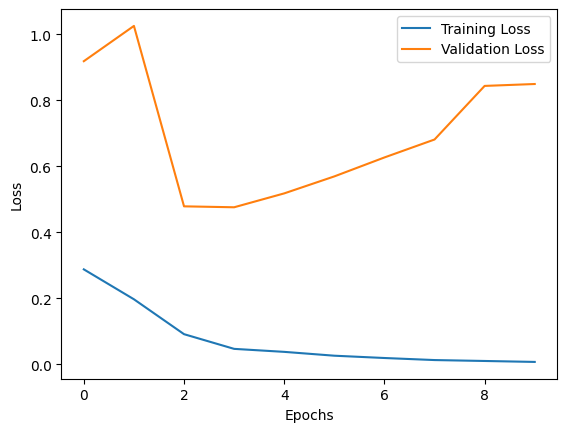

In [53]:
plt.plot(history_cnn2.history['loss'], label='Training Loss')
plt.plot(history_cnn2.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

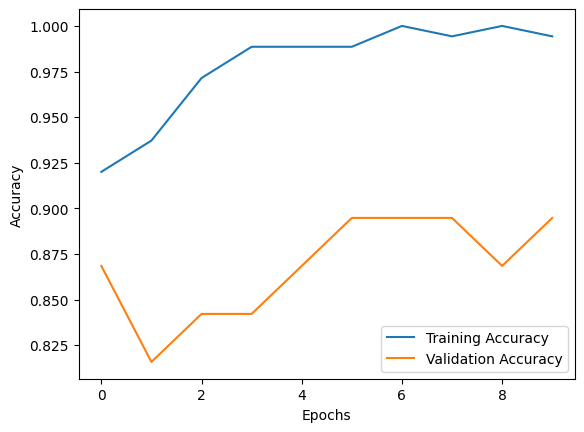

In [55]:
plt.plot(history_cnn2.history['accuracy'], label='Training Accuracy')
plt.plot(history_cnn2.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()